1. Set Up & Installation

In [28]:
import os
import json
import cv2
import numpy as np
import onnxruntime as ort
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from tqdm import tqdm
from torchvision.ops import box_convert, box_iou
from torch.utils.data import Dataset
from PIL import Image
import torch



2. Path Config

In [29]:
ANN_PATH = r"D:\Skripsi_Raphaela\rt_detr\dataset\split_dataset\annotations\test.json"
IMG_DIR  = r"D:\Skripsi_Raphaela\rt_detr\dataset\split_dataset\test"
MODEL_PATH = r"D:\Skripsi_Raphaela\rt_detr\program\rt_detr_int8.onnx"
INPUT_SIZE = 1024

# Adjusted thresholds for Sigmoid probabilities
PER_CLASS_THRESHOLDS = {
    0: 0.15,  # Excavator
    1: 0.06,  # Pillar
    2: 0.05,  # Rock
    3: 0.08,  # Traffic Cone
    4: 0.15   # Truck
}

# Mapping for visualization text
CLASS_NAMES = {
    0: "Excavator",
    1: "Pillar",
    2: "Rock",
    3: "Traffic Cone",
    4: "Truck"
}

3. Helper Function

In [30]:
def sigmoid(x):
    # Converts raw logits to probabilities [0, 1]
    return 1.0 / (1.0 + np.exp(-np.clip(x, -15, 15)))

def preprocess_image(image, size):
    # Standard RT-DETR preprocessing with ImageNet normalization
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img = img.astype(np.float32) / 255.0
    
    # ImageNet Mean & Std
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = (img - mean) / std
    
    # HWC to CHW
    return np.transpose(img, (2, 0, 1))

4. Model Initialization

In [31]:
import onnxruntime as ort
print(ort.get_available_providers())

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [32]:
# 1. Load Ground Truth
coco_gt = COCO(ANN_PATH)
img_ids = coco_gt.getImgIds()

# 2. Load ONNX Session (GPU Acceleration)
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
session = ort.InferenceSession(MODEL_PATH, providers=providers)
input_name = session.get_inputs()[0].name

results = []
visualized_count = 0

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


5. Inference Loop & Visualization

In [33]:
print(f"Starting evaluation on {len(img_ids)} images...")

for img_id in tqdm(img_ids):
    img_info = coco_gt.loadImgs(img_id)[0]
    file_path = os.path.join(IMG_DIR, img_info['file_name'])
    
    image = cv2.imread(file_path)
    if image is None: continue
    h_orig, w_orig = image.shape[:2]
    vis_image = image.copy()
    
    # Preprocess and Inference
    input_data = preprocess_image(image, INPUT_SIZE)
    input_tensor = np.expand_dims(input_data, axis=0)
    
    outputs = session.run(None, {input_name: input_tensor})
    all_class_logits, all_boxes = outputs[0][0], outputs[1][0]
    all_class_scores = sigmoid(all_class_logits)
    
    drew_boxes = False 
    for i in range(300):
        score = np.max(all_class_scores[i])
        class_id = int(np.argmax(all_class_scores[i]))

        if score > PER_CLASS_THRESHOLDS.get(class_id, 0.15):
            cx_n, cy_n, w_n, h_n = all_boxes[i]
            
            # Map normalized [cx, cy, w, h] to absolute [xmin, ymin, w, h]
            w = w_n * w_orig
            h = h_n * h_orig
            xmin = (cx_n * w_orig) - (w / 2)
            ymin = (cy_n * h_orig) - (h / 2)
            
            results.append({
                "image_id": img_id,
                "category_id": class_id,
                "bbox": [float(xmin), float(ymin), float(w), float(h)],
                "score": float(score)
            })
            
            # Visualization Logic for first 3 successful detections
            if visualized_count < 3:
                cv2.rectangle(vis_image, (int(xmin), int(ymin)), 
                              (int(xmin + w), int(ymin + h)), (0, 255, 0), 2)
                label = f"{CLASS_NAMES.get(class_id, 'Obj')} {score:.2f}"
                cv2.putText(vis_image, label, (int(xmin), int(ymin) - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                drew_boxes = True

    if visualized_count < 3 and drew_boxes:
        cv2.imwrite(f"int8_eval_vis_{visualized_count + 1}.jpg", vis_image)
        visualized_count += 1

Starting evaluation on 149 images...


100%|██████████| 149/149 [04:57<00:00,  1.99s/it]


6. Metric Summary

In [37]:
import numpy as np

if len(results) > 0:
    with open("temp_int8_results.json", "w") as f:
        json.dump(results, f)
        
    coco_dt = coco_gt.loadRes("temp_int8_results.json")
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    
    # --- ADDED: Per-Class mAP Extraction ---
    print("\n" + "="*50)
    print(" Per-Class Average Precision (AP @ IoU=0.50:0.95)")
    print("="*50)
    
    # The 'precision' array has a shape of [T, R, K, A, M]
    # T = IoU Thresholds, R = Recall Thresholds, K = Categories, A = Area, M = Max Detections
    precisions = coco_eval.eval['precision']
    cat_ids = coco_eval.params.catIds
    
    for i, cat_id in enumerate(cat_ids):
        # Index 0 for Area 'all', Index 2 for maxDets 100
        p = precisions[:, :, i, 0, 2] 
        # Remove -1 values (which indicate ignore/no ground truth)
        p = p[p > -1] 
        
        class_name = CLASS_NAMES.get(cat_id, f"Class {cat_id}")
        
        if len(p) > 0:
            ap = np.mean(p)
            print(f"{class_name:>15}: {ap:.3f}")
        else:
            print(f"{class_name:>15}: 0.000 (No valid matches)")
            
    print("="*50)
    print(f"\nEvaluation Complete. Saved {visualized_count} samples.")
else:
    print("No object detected. Check your model calibration or thresholds.")

Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.13s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.760
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.862
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.818
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.643
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.767
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.652
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.819
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.821
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [35]:
import torch
import json
from torch.utils.data import Dataset
from PIL import Image
from torchvision.ops import box_convert, box_iou

# 1. Definisikan Path (Sesuaikan dengan folder proyek Anda)
VAL_ANN_PATH = r"D:\Skripsi_Raphaela\rt_detr\dataset\split_dataset\annotations\val.json"
VAL_IMG_DIR  = r"D:\Skripsi_Raphaela\rt_detr\dataset\split_dataset\val"
IMG_SIZE = 1024  # Harus konsisten dengan saat training dan kalibrasi

class RTDETRDatasetEvaluation(Dataset):
    def __init__(self, coco_json_path, img_dir, img_size=1024):
        with open(coco_json_path, 'r') as f:
            self.coco_data = json.load(f)
        self.img_dir = img_dir
        self.img_size = img_size
        self.images = self.coco_data['images']
        
        # Buat mapping annotation berdasarkan image_id
        self.annotations = {}
        for ann in self.coco_data['annotations']:
            img_id = ann['image_id']
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        
        # Load dan Preprocess Gambar (Harus sama dengan skrip evaluasi Anda)
        image = Image.open(img_path).convert("RGB").resize((self.img_size, self.img_size))
        img_data = np.array(image).astype(np.float32) / 255.0
        
        # Normalisasi ImageNet
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_data = (img_data - mean) / std
        img_data = np.transpose(img_data, (2, 0, 1))

        # Ambil Label Ground Truth
        img_id = img_info['id']
        anns = self.annotations.get(img_id, [])
        
        boxes = []
        class_labels = []
        for ann in anns:
            # COCO format: [xmin, ymin, w, h] -> diubah ke [cx, cy, w, h] normalized
            xmin, ymin, w, h = ann['bbox']
            boxes.append([
                (xmin + w/2) / img_info['width'], 
                (ymin + h/2) / img_info['height'], 
                w / img_info['width'], 
                h / img_info['height']
            ])
            class_labels.append(ann['category_id'])

        return {
            "pixel_values": img_data,
            "labels": {
                "boxes": boxes,
                "class_labels": np.array(class_labels)
            }
        }

# 2. Inisialisasi variabel val_dataset
print("Loading validation dataset for evaluation...")
val_dataset = RTDETRDatasetEvaluation(VAL_ANN_PATH, VAL_IMG_DIR, img_size=IMG_SIZE)
print(f"Total images in val_dataset: {len(val_dataset)}")

Loading validation dataset for evaluation...
Total images in val_dataset: 288


Generating Confusion Matrix for INT8 Model with Class-Specific Thresholds...


100%|██████████| 288/288 [09:14<00:00,  1.93s/it]


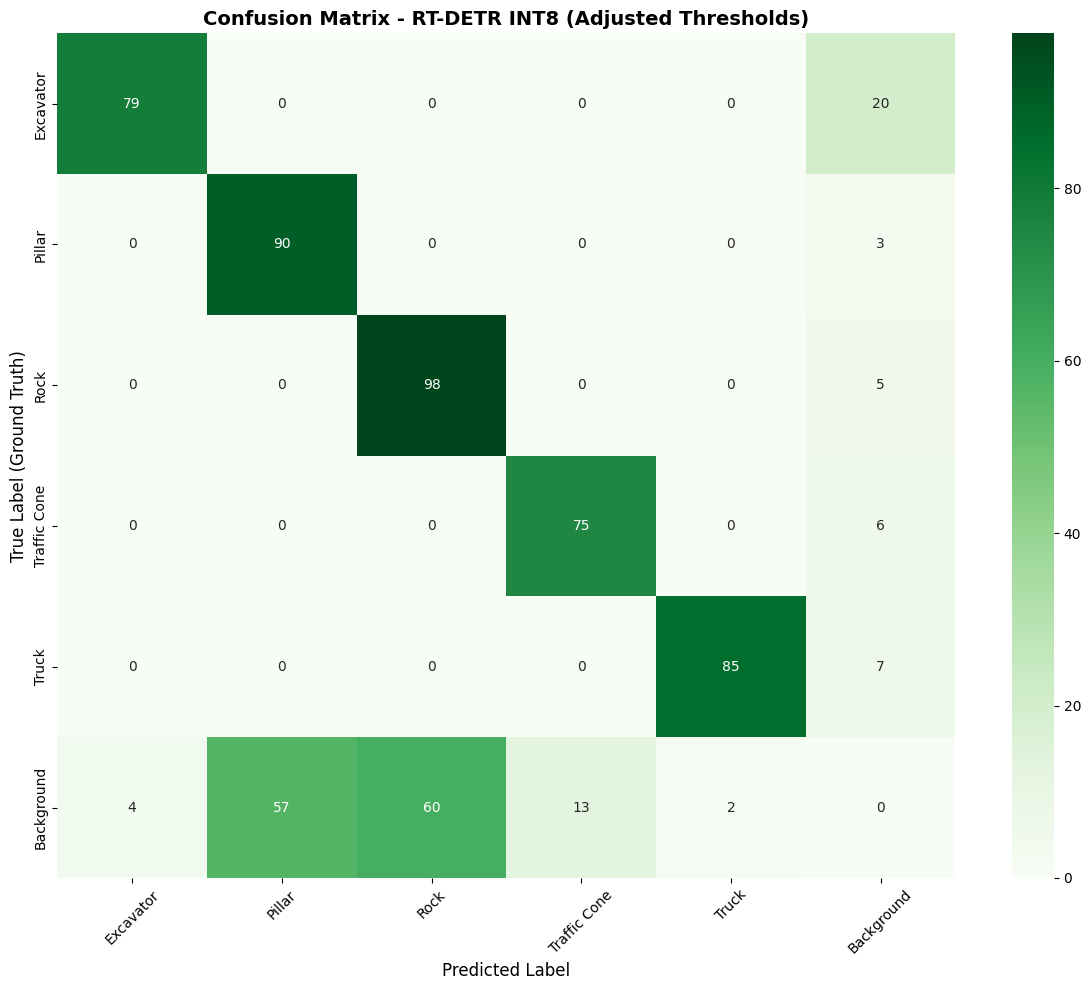


Classification Report for INT8 Model (Adjusted Thresholds):
              precision    recall  f1-score   support

   Excavator       0.95      0.80      0.87        99
      Pillar       0.61      0.97      0.75        93
        Rock       0.62      0.95      0.75       103
Traffic Cone       0.85      0.93      0.89        81
       Truck       0.98      0.92      0.95        92
  Background       0.00      0.00      0.00       136

    accuracy                           0.71       604
   macro avg       0.67      0.76      0.70       604
weighted avg       0.62      0.71      0.65       604



In [36]:
def get_confusion_matrix_rtdetr_int8(session, dataset, class_thresholds, device="cpu", iou_threshold=0.45):
    """
    Generate Confusion Matrix specifically for RT-DETR INT8 ONNX models,
    using class-specific thresholds and including a Background class.
    """
    all_true_labels = []
    all_pred_labels = []
    
    CLASSES = ["Excavator", "Pillar", "Rock", "Traffic Cone", "Truck", "Background"]
    BG_CLASS_ID = 5 
    
    input_name = session.get_inputs()[0].name
    
    print(f"Generating Confusion Matrix for INT8 Model with Class-Specific Thresholds...")

    for element in tqdm(dataset):
        # 1. Prepare Input
        pixel_values = np.expand_dims(element["pixel_values"], axis=0).astype(np.float32)
        gt_info = element["labels"] 
        
        # 2. Model Inference
        outputs = session.run(None, {input_name: pixel_values})
        logits, boxes = outputs[0][0], outputs[1][0]
        
        scores = 1.0 / (1.0 + np.exp(-np.clip(logits, -15, 15)))
        
        # 3. Post-Processing Predictions using class_thresholds
        pred_labels = []
        pred_boxes = []
        
        for i in range(300):
            score = np.max(scores[i])
            class_id = int(np.argmax(scores[i]))
            
            # KEY FIX: Use the specific threshold for the detected class
            current_threshold = class_thresholds.get(class_id, 0.15)
            
            if score > current_threshold:
                cx, cy, w, h = boxes[i]
                x1 = cx - w/2
                y1 = cy - h/2
                x2 = cx + w/2
                y2 = cy + h/2
                pred_boxes.append([x1, y1, x2, y2])
                pred_labels.append(class_id)
        
        pred_boxes = torch.tensor(pred_boxes)
        
        # 4. Prepare Ground Truth Boxes
        gt_boxes = torch.tensor(gt_info["boxes"]) 
        gt_class_labels = gt_info["class_labels"].tolist()
        
        if gt_boxes.shape[0] > 0:
            gt_boxes = box_convert(gt_boxes, 'cxcywh', 'xyxy')

        # 5. Matching logic
        if len(pred_boxes) > 0 and len(gt_boxes) > 0:
            iou_matrix = box_iou(gt_boxes, pred_boxes)
            matched_pred_indices = set()
            
            for i, gt_label in enumerate(gt_class_labels):
                ious = iou_matrix[i]
                max_iou, max_idx = torch.max(ious, dim=0)
                
                if max_iou >= iou_threshold:
                    all_true_labels.append(gt_label)
                    all_pred_labels.append(pred_labels[max_idx.item()])
                    matched_pred_indices.add(max_idx.item())
                else:
                    all_true_labels.append(gt_label)
                    all_pred_labels.append(BG_CLASS_ID)

            for j, pred_label in enumerate(pred_labels):
                if j not in matched_pred_indices:
                    all_true_labels.append(BG_CLASS_ID)
                    all_pred_labels.append(pred_label)
                    
        elif len(gt_boxes) > 0 and len(pred_boxes) == 0:
            for gt_label in gt_class_labels:
                all_true_labels.append(gt_label)
                all_pred_labels.append(BG_CLASS_ID)
                
        elif len(pred_boxes) > 0 and len(gt_boxes) == 0:
            for pred_label in pred_labels:
                all_true_labels.append(BG_CLASS_ID)
                all_pred_labels.append(pred_label)

    # 6. Generate Plot
    cm = confusion_matrix(all_true_labels, all_pred_labels, labels=list(range(len(CLASSES))))
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label (Ground Truth)', fontsize=12)
    plt.title('Confusion Matrix - RT-DETR INT8 (Adjusted Thresholds)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.show()

    # 7. Print Text Report
    print("\nClassification Report for INT8 Model (Adjusted Thresholds):")
    print(classification_report(all_true_labels, all_pred_labels, 
                                target_names=CLASSES, labels=list(range(len(CLASSES))),
                                zero_division=0))

# --- EXECUTION ---
PER_CLASS_THRESHOLDS = {
    0: 0.15,  # Excavator
    1: 0.06,  # Pillar
    2: 0.05,  # Rock
    3: 0.08,  # Traffic Cone
    4: 0.15   # Truck
}

session_int8 = ort.InferenceSession(r"D:\Skripsi_Raphaela\rt_detr\program\rt_detr_int8.onnx", 
                                    providers=['CPUExecutionProvider'])

# Pass the thresholds dictionary into the function
get_confusion_matrix_rtdetr_int8(session_int8, val_dataset, class_thresholds=PER_CLASS_THRESHOLDS, device="cpu")